# LLM Sentiment Analysis Benchmark: Indonesian Stock-Market Tweets
**Dataset:** ID-SMSA — `IDSMSA.csv` (Indonesian stock-market tweets, gold sentiment labels)
**Models compared:** Claude (Anthropic) · GPT-4o (OpenAI) · Grok (xAI) · DeepSeek
**Task:** 3-class sentiment classification — **Positive / Neutral / Negative**
**Metrics:** Classification quality (accuracy / macro-F1 / precision / recall), latency, token usage, and total cost

---
***Models Comparison Table:***
| Provider | Model | Input ($/1M) | Output ($/1M) | Context Window | Status |
|---|---|---|---|---|---|
| Anthropic | Claude Fable 5 | $10.00 | $50.00 | 1M | ✅ Newest flagship |
| Anthropic | Claude Mythos 5 | $10.00 | $50.00 | 1M | ✅ Project Glasswing only |
| Anthropic | Claude Opus 4.8 | $5.00 | $25.00 | 1M | ✅ Current |
| Anthropic | Claude Opus 4.7 | $5.00 | $25.00 | 1M | ✅ Current |
| Anthropic | Claude Opus 4.6 | $5.00 | $25.00 | 1M | ✅ Current |
| Anthropic | Claude Sonnet 4.6 | $3.00 | $15.00 | 1M | ✅ Recommended production |
| Anthropic | Claude Haiku 4.5 | $1.00 | $5.00 | 200K | ✅ Budget / high-volume |
| Anthropic | Claude Haiku 3.5 | $0.80 | $4.00 | 200K | ⚠️ Legacy |
| Anthropic | Claude Haiku 3 | $0.25 | $1.25 | 200K | ⚠️ Legacy |
| Anthropic | Claude Opus 4.1 | $15.00 | $75.00 | 200K | ⚠️ Legacy |
| OpenAI | GPT-5.5 Pro | $30.00 | $180.00 | 1M+ | ✅ Highest-stakes reasoning |
| OpenAI | GPT-5.5 | $5.00 | $30.00 | 1M+ | ✅ Current flagship |
| OpenAI | GPT-5.4 | $2.50 | $15.00 | 1M | ✅ Recommended production |
| OpenAI | GPT-5.4 Mini | $0.75 | $4.50 | 1M | ✅ Budget general use |
| OpenAI | GPT-5.4 Nano | $0.20 | $1.25 | 1M | ✅ Ultra-budget |
| OpenAI | GPT-4.1 | $2.00 | $8.00 | 1M | ✅ Long-context budget |
| OpenAI | GPT-4.1 Mini | $0.40 | $1.60 | 1M | ✅ Long-context budget |
| OpenAI | GPT-4o | $2.50 | $10.00 | 128K | ⚠️ Legacy multimodal |
| OpenAI | GPT-4o Mini | $0.15 | $0.60 | 128K | ⚠️ Legacy budget |
| xAI | Grok 4.3 | $1.25 | $2.50 | 1M | ✅ Current flagship |
| xAI | Grok 4.1 Fast | $0.20 | $0.50 | 2M | ✅ Budget / high-volume |
| xAI | Grok 4 | $3.00 | $15.00 | 256K | ⚠️ Legacy |
| xAI | Grok 3 | $2.00 | $10.00 | 131K | ⚠️ Legacy |
| xAI | Grok 3 Mini | $0.30 | $0.50 | 131K | ⚠️ Legacy |
| DeepSeek | DeepSeek V4 Flash | $0.14 | $0.28 | 1M | ✅ Cost-effective flagship |
| DeepSeek | deepseek-chat *(alias)* | $0.14 | $0.28 | 1M | ⚠️ → V4 Flash |

*Prices are subject to change. Always verify against official provider documentation before committing to production budgets.*
- Anthropic: https://platform.claude.com/docs/en/about-claude/pricing
- OpenAI: https://developers.openai.com/api/docs/pricing
- xAI: https://docs.x.ai/docs/models
- DeepSeek: https://api-docs.deepseek.com/quick_start/pricing


## 1. Install dependencies

In [2]:
%pip install -q anthropic openai requests scikit-learn pandas matplotlib seaborn tqdm python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration — API keys & model names
Set your keys in a `.env` file, in `API_KEY.txt`, or directly below.

In [3]:
import os
from dotenv import load_dotenv


# Load API keys from API_KEY.txt if it exists
if os.path.exists("API_KEY.txt"):
    with open("API_KEY.txt", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip()

load_dotenv()

# ── API Keys ──────────────────────────────────────────────────────────────────
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY",    "")
XAI_API_KEY       = os.getenv("XAI_API_KEY",       "")
DEEPSEEK_API_KEY  = os.getenv("DEEPSEEK_API_KEY",  "")

# ── Model identifiers ─────────────────────────────────────────────────────────
MODELS = {
    "claude":   "claude-sonnet-4-6",
    "openai":   "gpt-4o",
    "xai":      "grok-3",
    "deepseek": "deepseek-chat",
}

# ── Pricing (USD per 1 M tokens) — update as needed ──────────────────────────
# Format: {model_key: (input_price_per_1M, output_price_per_1M)}
PRICING = {
    "claude":   (3.00,  15.00),   # claude-sonnet-4-6
    "openai":   (2.50,  10.00),   # gpt-4o
    "xai":      (2.00,  10.00),   # grok-3 (verify on x.ai)
    "deepseek": (0.14,   0.28),   # deepseek-chat V3
}

# ── Benchmark settings ────────────────────────────────────────────────────────
LABELS          = ["Positive", "Neutral", "Negative"]   # canonical gold labels
N_SAMPLES       = 100   # number of tweets to evaluate (per model)
REQUEST_TIMEOUT = 60    # seconds per request

print("Configuration loaded.")

Configuration loaded.


## 3. Load the ID-SMSA sentiment dataset
`IDSMSA.csv` — column `Sentence` holds the Indonesian tweet, `Sentiment` the gold label. We keep only valid-labelled rows and take a stratified sample so every model sees the same class balance.

In [4]:
import pandas as pd

CSV_PATH = "../../data/IDSMSA.csv"

df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded raw {len(df_raw)} rows from {CSV_PATH}")
print("\nSentiment distribution (full dataset):")
print(df_raw["Sentiment"].value_counts())
print(len(df_raw))


# Keep rows with a valid gold label and non-empty text
clean = df_raw[df_raw["Sentiment"].isin(LABELS)].copy()
clean = clean[clean["Sentence"].astype(str).str.strip().astype(bool)]

# Stratified sample so the class balance matches the full set
if N_SAMPLES is None or N_SAMPLES >= len(clean):
    df_dataset = clean.reset_index(drop=True)
else:
    df_dataset = (
        clean.groupby("Sentiment", group_keys=False)
        .apply(lambda g: g.sample(n=max(1, round(N_SAMPLES * len(g) / len(clean))),
                                   random_state=42))
        .reset_index(drop=True)
    )

print(f"\nEvaluating on {len(df_dataset)} tweets")
print(df_dataset["Sentiment"].value_counts())
df_dataset[["Sentence", "Sentiment"]].head(10)

Loaded raw 3288 rows from ../../data/IDSMSA.csv

Sentiment distribution (full dataset):
Sentiment
Positive    1769
Negative     786
Neutral      733
Name: count, dtype: int64
3288

Evaluating on 100 tweets
Sentiment
Positive    54
Negative    24
Neutral     22
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4236\1676358942.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=max(1, round(N_SAMPLES * len(g) / len(clean))),


,Sentence,Sentiment
0,[USERNAME] [USERNAME] Kenapa bisa turun 4800? ...,Negative
1,Cuma penasaran yg dulu mas kawin pake saham $U...,Negative
2,"IHSG melemah 0,75 persen ke 6.652 pada penutup...",Negative
3,"IHSG Sesi I Melemah ke 6.876, Saham BBCA, TLKM...",Negative
4,[USERNAME] Pastikan perusahaannya tidak banyak...,Negative
5,"IHSG Hari Ini Diramal Memerah, Cek Rekomendasi...",Negative
6,"IHSG ditutup melemah 0,67 persen ke 6.636,42 p...",Negative
7,Beli Saham Orang Terkaya RI Follower saya beli...,Negative
8,Inflasi Amerika Serikat (AS) berada di atas ek...,Negative
9,Bu guru yoshinaga pun terdiam karna teringat d...,Negative


## 4. API client helpers

Each helper sends the tweet to one provider and returns:
`{prediction, latency_s, input_tokens, output_tokens, cost_usd, raw}`

All four use the same prompt. The reply is parsed leniently — anything that does not contain
one of the three labels becomes `"Unknown"` (counted as a miss).

In [5]:
import time
import anthropic
import openai

SYSTEM_PROMPT = (
    "You are a sentiment-analysis classifier for Indonesian stock-market tweets. "
    "Classify the overall sentiment of the tweet toward the stock/market as exactly one of: "
    "Positive, Neutral, Negative. "
    "Reply with ONLY that single word and nothing else."
)


def _cost(model_key, in_tok, out_tok):
    ip, op = PRICING[model_key]
    return (in_tok * ip + out_tok * op) / 1_000_000


def parse_label(raw: str) -> str:
    """Map a free-text reply to one of the canonical labels (or 'Unknown')."""
    if not raw:
        return "Unknown"
    low = raw.strip().lower()
    hits = [(low.find(l.lower()), l) for l in LABELS if l.lower() in low]
    return min(hits)[1] if hits else "Unknown"


# ── Claude (Anthropic) ────────────────────────────────────────────────────────
def classify_claude(text):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    t0 = time.perf_counter()
    msg = client.messages.create(
        model=MODELS["claude"], max_tokens=16,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": text}],
    )
    lat = time.perf_counter() - t0
    raw = "".join(b.text for b in msg.content if getattr(b, "type", None) == "text").strip()
    return {
        "prediction":    parse_label(raw),
        "raw":           raw,
        "latency_s":     lat,
        "input_tokens":  msg.usage.input_tokens,
        "output_tokens": msg.usage.output_tokens,
        "cost_usd":      _cost("claude", msg.usage.input_tokens, msg.usage.output_tokens),
    }


# ── OpenAI (GPT-4o) ───────────────────────────────────────────────────────────
def classify_openai(text):
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=MODELS["openai"], max_tokens=16,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": text}],
    )
    lat = time.perf_counter() - t0
    raw = (resp.choices[0].message.content or "").strip()
    return {
        "prediction":    parse_label(raw),
        "raw":           raw,
        "latency_s":     lat,
        "input_tokens":  resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
        "cost_usd":      _cost("openai", resp.usage.prompt_tokens, resp.usage.completion_tokens),
    }


# ── xAI / Grok (OpenAI-compatible) ────────────────────────────────────────────
def classify_xai(text):
    client = openai.OpenAI(api_key=XAI_API_KEY, base_url="https://api.x.ai/v1")
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=MODELS["xai"], max_tokens=16,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": text}],
    )
    lat = time.perf_counter() - t0
    raw = (resp.choices[0].message.content or "").strip()
    return {
        "prediction":    parse_label(raw),
        "raw":           raw,
        "latency_s":     lat,
        "input_tokens":  resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
        "cost_usd":      _cost("xai", resp.usage.prompt_tokens, resp.usage.completion_tokens),
    }


# ── DeepSeek (OpenAI-compatible) ──────────────────────────────────────────────
def classify_deepseek(text):
    client = openai.OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com/v1")
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=MODELS["deepseek"], max_tokens=16,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user",   "content": text}],
    )
    lat = time.perf_counter() - t0
    raw = (resp.choices[0].message.content or "").strip()
    return {
        "prediction":    parse_label(raw),
        "raw":           raw,
        "latency_s":     lat,
        "input_tokens":  resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
        "cost_usd":      _cost("deepseek", resp.usage.prompt_tokens, resp.usage.completion_tokens),
    }


CLASSIFIERS = {
    "claude":   classify_claude,
    "openai":   classify_openai,
    "xai":      classify_xai,
    "deepseek": classify_deepseek,
}

print("API helpers ready.")

API helpers ready.


## 5. Run the benchmark
Each tweet is sent to all four models. Errors are caught and logged without halting the run.

In [6]:
import traceback
from tqdm.notebook import tqdm

records = []

for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Tweets"):
    text = row["Sentence"]
    gold = row["Sentiment"]

    for model_key, fn in CLASSIFIERS.items():
        try:
            r = fn(text)
            records.append({
                "tweet_idx":     idx,
                "model":         model_key,
                "sentence":      text,
                "gold":          gold,
                "prediction":    r["prediction"],
                "raw":           r["raw"],
                "latency_s":     r["latency_s"],
                "input_tokens":  r["input_tokens"],
                "output_tokens": r["output_tokens"],
                "total_tokens":  r["input_tokens"] + r["output_tokens"],
                "cost_usd":      r["cost_usd"],
            })
        except Exception as e:
            print(f"[{model_key}] tweet {idx} failed: {e}")
            traceback.print_exc()

df_results = pd.DataFrame(records)
print(f"Collected {len(df_results)} results.")
df_results.head(8)

Tweets:   0%|          | 0/100 [00:00<?, ?it/s]

Collected 400 results.


,tweet_idx,model,sentence,gold,prediction,raw,latency_s,input_tokens,output_tokens,total_tokens,cost_usd
0,0,claude,[USERNAME] [USERNAME] Kenapa bisa turun 4800? ...,Negative,Positive,Positive,1.266994,161,5,166,0.000558
1,0,openai,[USERNAME] [USERNAME] Kenapa bisa turun 4800? ...,Negative,Neutral,Neutral,2.228324,130,1,131,0.000335
2,0,xai,[USERNAME] [USERNAME] Kenapa bisa turun 4800? ...,Negative,Neutral,Neutral,12.191869,323,1,324,0.000656
3,0,deepseek,[USERNAME] [USERNAME] Kenapa bisa turun 4800? ...,Negative,Positive,Positive,0.678343,136,1,137,0.000019
4,1,claude,Cuma penasaran yg dulu mas kawin pake saham $U...,Negative,Negative,Negative,1.050917,90,5,95,0.000345
5,1,openai,Cuma penasaran yg dulu mas kawin pake saham $U...,Negative,Neutral,Neutral,1.050404,76,1,77,0.000200
6,1,xai,Cuma penasaran yg dulu mas kawin pake saham $U...,Negative,Negative,Negative,6.546001,262,1,263,0.000534
7,1,deepseek,Cuma penasaran yg dulu mas kawin pake saham $U...,Negative,Neutral,Neutral,0.720696,75,2,77,0.000011


## 6. Classification quality — accuracy, precision, recall, F1

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

quality_rows = []
for model_key, grp in df_results.groupby("model"):
    y_true = grp["gold"].tolist()
    y_pred = grp["prediction"].tolist()
    quality_rows.append({
        "model":     model_key,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0), 4),
        "F1_macro":  round(f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0), 4),
    })

df_quality = pd.DataFrame(quality_rows).set_index("model")
print(df_quality)

# Per-model per-class report
for model_key, grp in df_results.groupby("model"):
    print(f"\n===== {model_key} ({MODELS[model_key]}) =====")
    print(classification_report(grp["gold"], grp["prediction"],
                                labels=LABELS, zero_division=0))

          Accuracy  Precision  Recall  F1_macro
model                                          
claude        0.83     0.8039  0.7898    0.7928
deepseek      0.73     0.7138  0.7010    0.7021
openai        0.74     0.7707  0.7663    0.7390
xai           0.85     0.8277  0.8227    0.8242

===== claude (claude-sonnet-4-6) =====
              precision    recall  f1-score   support

    Positive       0.86      0.91      0.88        54
     Neutral       0.71      0.55      0.62        22
    Negative       0.85      0.92      0.88        24

    accuracy                           0.83       100
   macro avg       0.80      0.79      0.79       100
weighted avg       0.82      0.83      0.82       100


===== deepseek (deepseek-chat) =====
              precision    recall  f1-score   support

    Positive       0.80      0.80      0.80        54
     Neutral       0.56      0.68      0.61        22
    Negative       0.79      0.62      0.70        24

    accuracy                       

## 7. Aggregate performance metrics

In [8]:
df_agg = (
    df_results.groupby("model")
    .agg(
        avg_latency_s  = ("latency_s",     "mean"),
        p50_latency_s  = ("latency_s",     lambda x: x.quantile(0.50)),
        p95_latency_s  = ("latency_s",     lambda x: x.quantile(0.95)),
        avg_input_tok  = ("input_tokens",  "mean"),
        avg_output_tok = ("output_tokens", "mean"),
        total_tokens   = ("total_tokens",  "sum"),
        total_cost_usd = ("cost_usd",      "sum"),
        avg_cost_usd   = ("cost_usd",      "mean"),
    )
    .round(5)
)

df_summary = df_agg.join(df_quality)
df_summary

,avg_latency_s,p50_latency_s,p95_latency_s,avg_input_tok,avg_output_tok,total_tokens,total_cost_usd,avg_cost_usd,Accuracy,Precision,Recall,F1_macro
model,,,,,,,,,,,,
claude,1.37997,1.15018,2.43892,118.39,5.00,12339,0.04302,0.00043,0.83,0.8039,0.7898,0.7928
deepseek,0.64180,0.62295,0.81843,98.49,1.27,9976,0.00141,0.00001,0.73,0.7138,0.7010,0.7021
openai,0.79556,0.73533,1.15820,101.30,1.00,10230,0.02632,0.00026,0.74,0.7707,0.7663,0.7390
xai,5.38568,4.75375,8.27946,285.60,1.00,28660,0.05812,0.00058,0.85,0.8277,0.8227,0.8242


## 8. Save results to CSV

In [9]:
df_results.to_csv("result/sentiment_benchmark_raw.csv", index=False)
df_summary.to_csv("summary/sentiment_benchmark_summary.csv")
print("Saved: sentiment_benchmark_raw.csv  &  sentiment_benchmark_summary.csv")

Saved: sentiment_benchmark_raw.csv  &  sentiment_benchmark_summary.csv


## 9. Visualisations

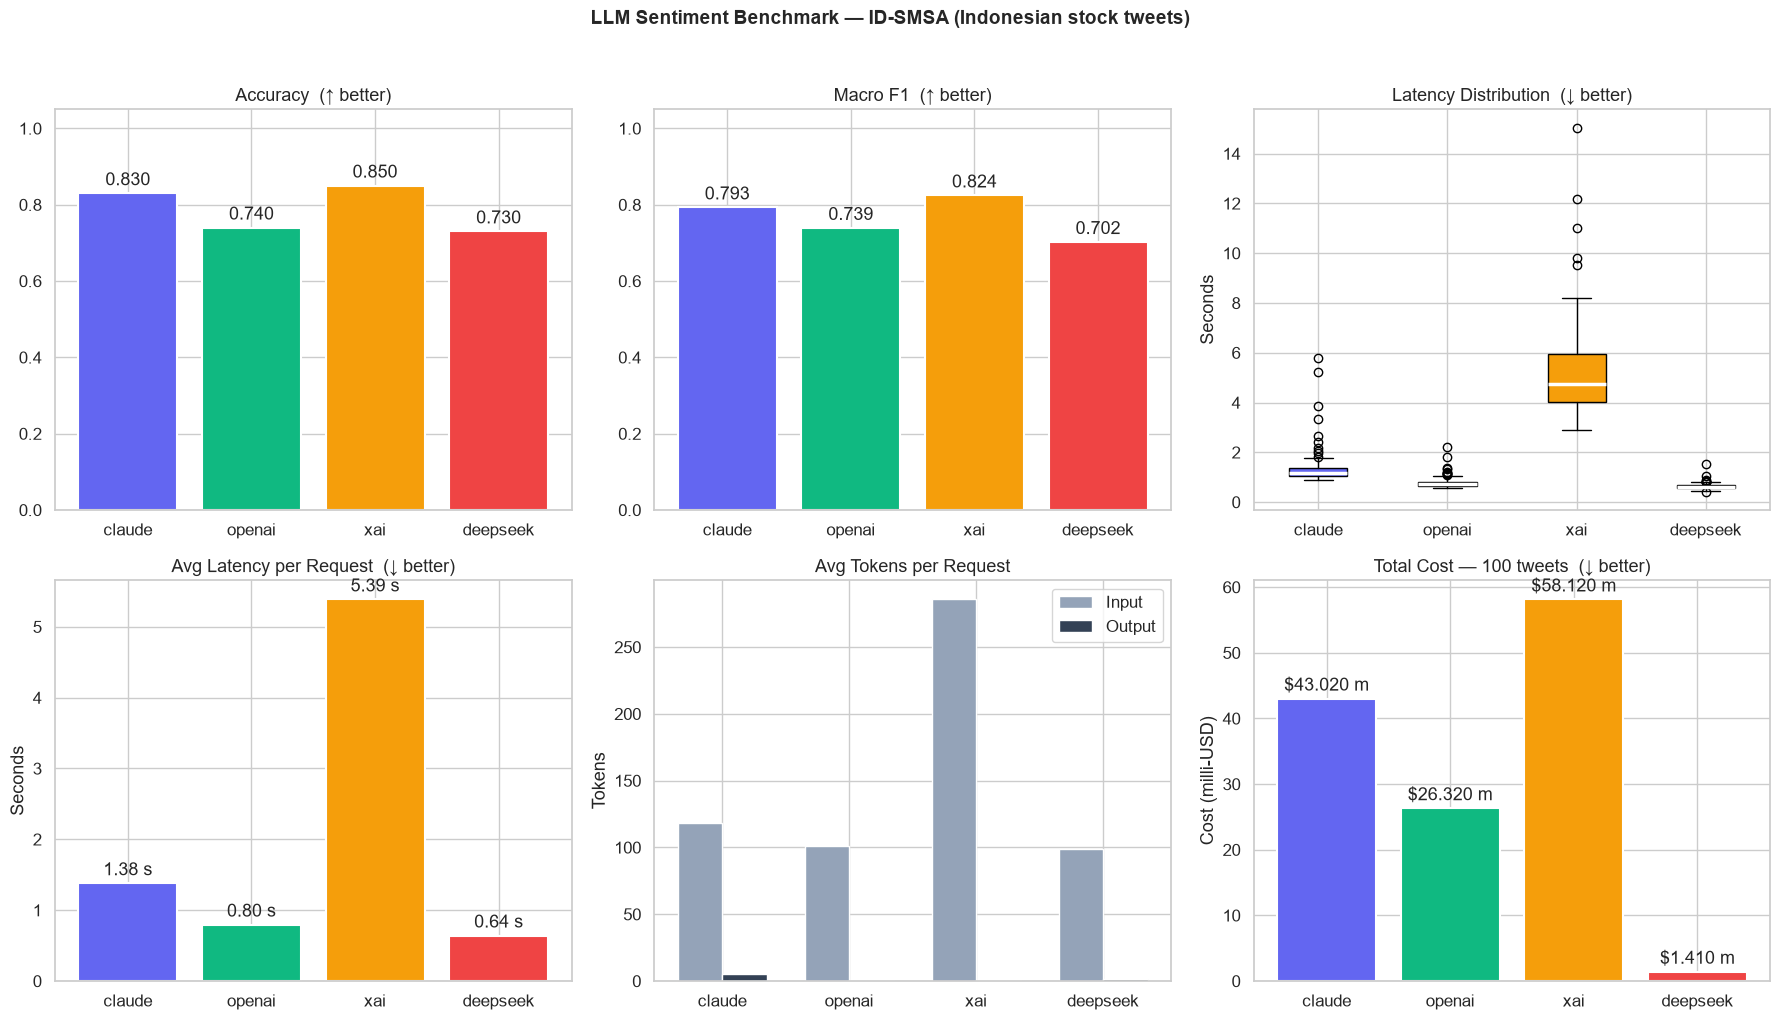

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE     = {"claude": "#6366f1", "openai": "#10b981", "xai": "#f59e0b", "deepseek": "#ef4444"}
MODEL_ORDER = [m for m in ["claude", "openai", "xai", "deepseek"] if m in df_summary.index]
COLORS      = [PALETTE[m] for m in MODEL_ORDER]

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LLM Sentiment Benchmark — ID-SMSA (Indonesian stock tweets)", fontsize=14, fontweight="bold", y=1.02)

# 9.1 Accuracy
ax = axes[0, 0]
vals = [df_summary.loc[m, "Accuracy"] for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="%.3f", padding=3)
ax.set_title("Accuracy  (↑ better)")
ax.set_ylim(0, 1.05)

# 9.2 Macro F1
ax = axes[0, 1]
vals = [df_summary.loc[m, "F1_macro"] for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="%.3f", padding=3)
ax.set_title("Macro F1  (↑ better)")
ax.set_ylim(0, 1.05)

# 9.3 Latency box
ax = axes[0, 2]
data_lat = [df_results[df_results["model"] == m]["latency_s"].values for m in MODEL_ORDER]

# bp = ax.boxplot(data_lat, labels=MODEL_ORDER, patch_artist=True,
#                 medianprops=dict(color="white", linewidth=2.5)) // Old Model Matplotlib

bp = ax.boxplot(data_lat, tick_labels=MODEL_ORDER, patch_artist=True,
                medianprops=dict(color="white", linewidth=2.5))
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c)
ax.set_title("Latency Distribution  (↓ better)")
ax.set_ylabel("Seconds")

# 9.4 Avg latency bar
ax = axes[1, 0]
vals = [df_summary.loc[m, "avg_latency_s"] for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="%.2f s", padding=3)
ax.set_title("Avg Latency per Request  (↓ better)")
ax.set_ylabel("Seconds")

# 9.5 Token breakdown
ax = axes[1, 1]
x = range(len(MODEL_ORDER))
w = 0.35
in_toks  = [df_summary.loc[m, "avg_input_tok"]  for m in MODEL_ORDER]
out_toks = [df_summary.loc[m, "avg_output_tok"] for m in MODEL_ORDER]
ax.bar([xi - w/2 for xi in x], in_toks,  w, label="Input",  color="#94a3b8", edgecolor="white")
ax.bar([xi + w/2 for xi in x], out_toks, w, label="Output", color="#334155", edgecolor="white")
ax.set_xticks(list(x)); ax.set_xticklabels(MODEL_ORDER); ax.legend()
ax.set_title("Avg Tokens per Request")
ax.set_ylabel("Tokens")

# 9.6 Total cost in milli-USD
ax = axes[1, 2]
vals = [df_summary.loc[m, "total_cost_usd"] * 1000 for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="$%.3f m", padding=3)
ax.set_title(f"Total Cost — {len(df_dataset)} tweets  (↓ better)")
ax.set_ylabel("Cost (milli-USD)")

plt.tight_layout()
plt.savefig("fig/sentiment_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 9b. Confusion matrices

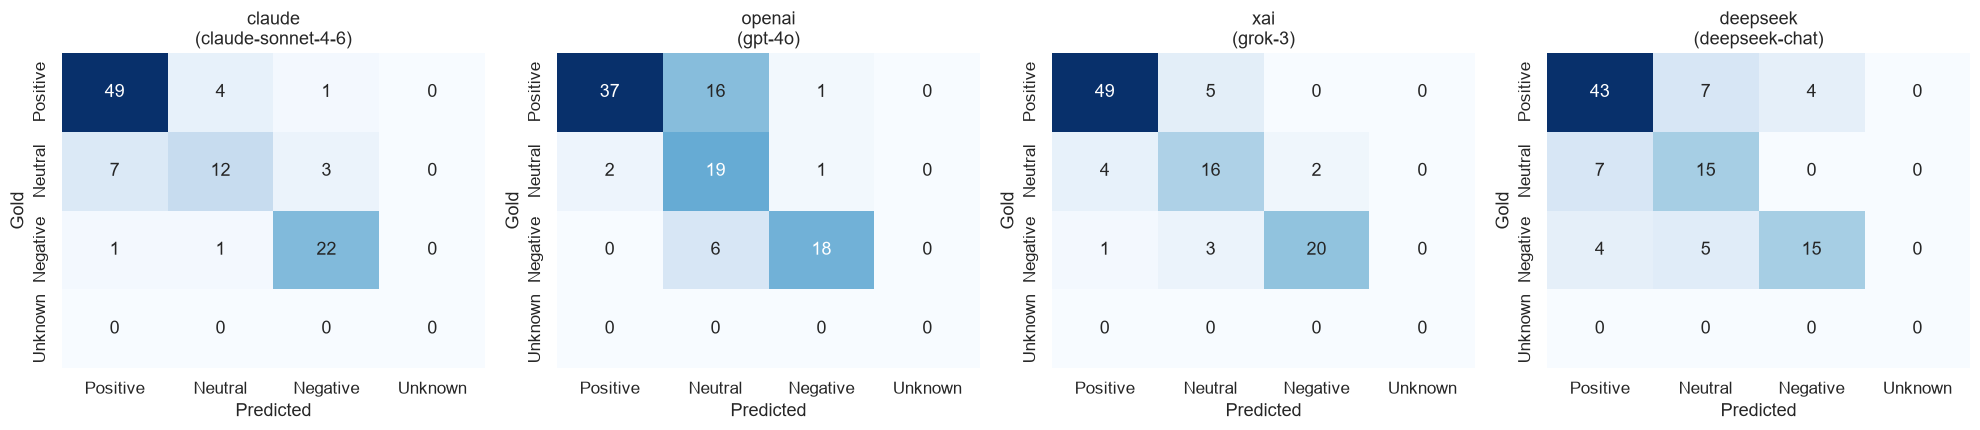

In [11]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(5 * len(MODEL_ORDER), 4.5))
if len(MODEL_ORDER) == 1:
    axes = [axes]
for ax, m in zip(axes, MODEL_ORDER):
    grp = df_results[df_results["model"] == m]
    order = LABELS + ["Unknown"]
    cm = confusion_matrix(grp["gold"], grp["prediction"], labels=order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=order, yticklabels=order, ax=ax)
    ax.set_title(f"{m}\n({MODELS[m]})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Gold")
plt.tight_layout()
plt.savefig("sentiment_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Cost vs Quality scatter

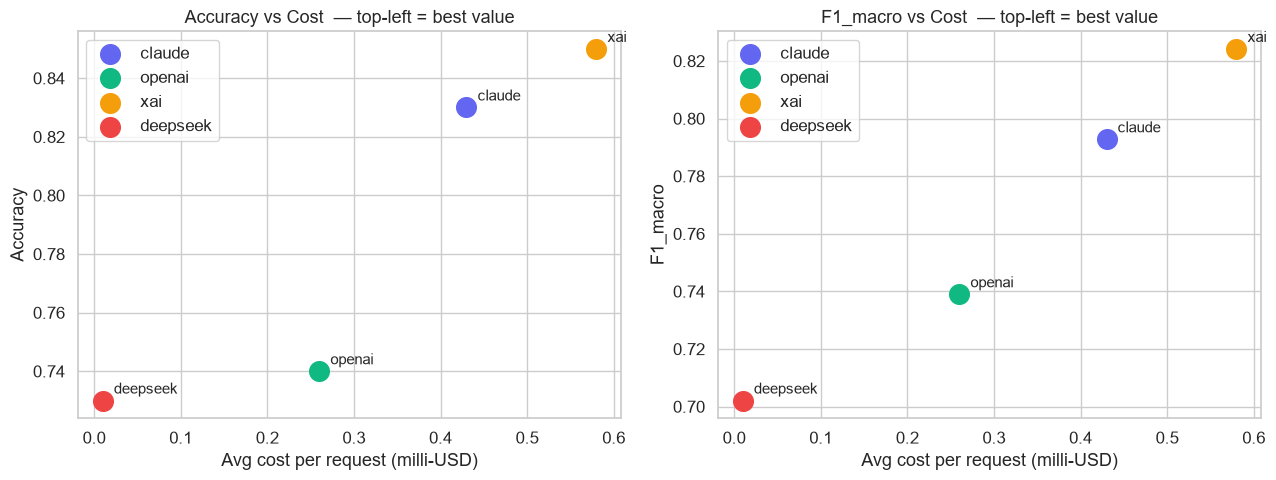

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["Accuracy", "F1_macro"]):
    for m in MODEL_ORDER:
        x = df_summary.loc[m, "avg_cost_usd"] * 1000
        y = df_summary.loc[m, metric]
        ax.scatter(x, y, s=200, color=PALETTE[m], zorder=5, label=m)
        ax.annotate(m, (x, y), textcoords="offset points", xytext=(8, 5), fontsize=11)
    ax.set_xlabel("Avg cost per request (milli-USD)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs Cost  — top-left = best value")
    ax.legend()

plt.tight_layout()
plt.savefig("fig/sentiment_cost_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Side-by-side prediction examples

In [13]:
idxs = df_dataset.index[:min(3, len(df_dataset))]

for idx in idxs:
    subset = df_results[df_results["tweet_idx"] == idx]
    if subset.empty:
        continue
    print(f"\n{'='*80}")
    print(f"Tweet #{idx}")
    print(f"  TEXT:  {df_dataset.loc[idx, 'Sentence']}")
    print(f"  GOLD:  {df_dataset.loc[idx, 'Sentiment']}")
    for _, row in subset.iterrows():
        mark = "✅" if row["prediction"] == row["gold"] else "❌"
        print(f"\n  [{row['model']:>8}] {mark} {row['prediction']:<10} (raw: {row['raw']!r})")
        print(f"            latency={row['latency_s']:.2f}s  "
              f"tokens={row['total_tokens']}  "
              f"cost=${row['cost_usd']*1000:.4f}m")


Tweet #0
  TEXT:  [USERNAME] [USERNAME] Kenapa bisa turun 4800? nah inilah ajaibnya pasar modal yang dipengaruhi oleh fear dan greed pas bulish pasti naiknya gak kira kira sampai berlebihan pas bearish kadang-kadang kebablasan jadi strategi diatas untuk masang jebakan (bubu) nangke ikan ASII di harga bawah
  GOLD:  Negative

  [  claude] ❌ Positive   (raw: 'Positive')
            latency=1.27s  tokens=166  cost=$0.5580m

  [  openai] ❌ Neutral    (raw: 'Neutral')
            latency=2.23s  tokens=131  cost=$0.3350m

  [     xai] ❌ Neutral    (raw: 'Neutral')
            latency=12.19s  tokens=324  cost=$0.6560m

  [deepseek] ❌ Positive   (raw: 'Positive')
            latency=0.68s  tokens=137  cost=$0.0193m

Tweet #1
  TEXT:  Cuma penasaran yg dulu mas kawin pake saham $UNVR apa kabar 🙃
  GOLD:  Negative

  [  claude] ✅ Negative   (raw: 'Negative')
            latency=1.05s  tokens=95  cost=$0.3450m

  [  openai] ❌ Neutral    (raw: 'Neutral')
            latency=1.05s  tokens=77  cost

## 12. Final leaderboard

In [14]:
leaderboard = df_summary[[
    "Accuracy", "Precision", "Recall", "F1_macro",
    "avg_latency_s", "p95_latency_s",
    "avg_input_tok", "avg_output_tok", "total_tokens",
    "avg_cost_usd", "total_cost_usd"
]].copy()

leaderboard["avg_cost_m"]   = (leaderboard.pop("avg_cost_usd")   * 1000).round(4)
leaderboard["total_cost_m"] = (leaderboard.pop("total_cost_usd") * 1000).round(4)
leaderboard.columns = [
    "Accuracy", "Precision", "Recall", "F1",
    "Avg Lat(s)", "P95 Lat(s)",
    "Avg InTok", "Avg OutTok", "Total Tok",
    "Avg Cost(m$)", "Total Cost(m$)"
]
leaderboard.sort_values("Accuracy", ascending=False, inplace=True)

display(
    leaderboard.style
    .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Greens")
    .background_gradient(subset=["Avg Lat(s)", "P95 Lat(s)"],              cmap="Reds_r")
    .background_gradient(subset=["Total Cost(m$)"],                        cmap="Oranges_r")
    .format(precision=3)
)

,Accuracy,Precision,Recall,F1,Avg Lat(s),P95 Lat(s),Avg InTok,Avg OutTok,Total Tok,Avg Cost(m$),Total Cost(m$)
model,,,,,,,,,,,
xai,0.850,0.828,0.823,0.824,5.386,8.279,285.600,1.000,28660,0.580,58.120
claude,0.830,0.804,0.790,0.793,1.380,2.439,118.390,5.000,12339,0.430,43.020
openai,0.740,0.771,0.766,0.739,0.796,1.158,101.300,1.000,10230,0.260,26.320
deepseek,0.730,0.714,0.701,0.702,0.642,0.818,98.490,1.270,9976,0.010,1.410


---
### Metric guide

| Metric | Direction | Notes |
|--------|-----------|-------|
| **Accuracy** | ↑ higher is better | Fraction of tweets whose predicted label matches the gold label |
| **Precision (macro)** | ↑ higher is better | Averaged over the 3 classes; penalises false positives |
| **Recall (macro)** | ↑ higher is better | Averaged over the 3 classes; penalises missed positives |
| **F1 (macro)** | ↑ higher is better | Harmonic mean of precision & recall; robust to class imbalance |
| **Latency** | ↓ lower is better | Wall-clock time per API call |
| **Tokens** | ↓ lower is better | Prompt engineering can reduce input tokens |
| **Cost** | ↓ lower is better | Derived from official per-token pricing |


# Tugas

Cobalah evaluasi performa pilihan model Anthropic, OpenAI, xAI, DeepSeek lainnya pada dataset di atas.
Beberapa ide:
- Ganti `MODELS` dengan tier lain (mis. `claude-haiku-4-5`, `gpt-4o-mini`, `grok-4.1-fast`) dan bandingkan trade-off biaya vs akurasi.
- Naikkan `N_SAMPLES` untuk hasil yang lebih stabil.
- Ubah `SYSTEM_PROMPT` (mis. few-shot atau minta output JSON) dan lihat pengaruhnya pada akurasi & jumlah token.